# DSA 210 — Personalized Well-being Prediction from Sleep & Lifestyle Data
**Author:** Deniz Elbek | **Milestone 2:** Machine Learning Models

This notebook applies machine learning to predict two personal outcomes — **morning feel rating** and **daily productivity rating** — from 34 nights of self-collected sleep, lifestyle, and environmental data (n=28 complete observations after excluding nights where the Apple Watch was not worn).

**Modelling strategy (per evaluator feedback):**
- Primary models: Ridge, Lasso, ElasticNet (regularized linear — appropriate for small n)
- Secondary comparisons: Random Forest, XGBoost
- Evaluation: Leave-One-Out Cross-Validation (LOOCV)
- Interpretation: SHAP values → personalized optimal routine recommendation

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.impute import SimpleImputer
import xgboost as xgb
import shap

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

df = pd.read_csv('../data/sleep_data.csv', parse_dates=['date'])
print(f'Full dataset: {df.shape[0]} rows × {df.shape[1]} cols')
df.head()

Full dataset: 34 rows × 24 cols


,date,bedtime_hour,wake_hour,duration_h,deep_min,rem_min,core_min,awake_min,sleep_efficiency,apple_sleep_score,...,resp_rate,steps,active_cal,exercise_min,caffeine_mg,last_caffeine_hour,alcohol_scale,last_meal_hour,morning_feel,productivity
0,2026-04-01,3.52,15.73,12.21,31.7,243.4,437.0,20.6,97.2,89.0,...,19.83,11444.0,376.4,20.0,300,2.0,2,3.0,10,0.0
1,2026-04-02,5.48,11.62,6.13,29.2,66.4,225.8,46.8,87.3,59.0,...,21.87,18549.0,749.5,33.0,300,14.0,5,1.5,8,0.0
2,2026-04-03,4.02,10.42,6.39,30.7,89.5,251.9,11.6,97.0,84.0,...,22.25,21513.0,629.8,46.0,480,21.0,0,20.0,10,0.0
3,2026-04-04,1.32,12.93,11.62,31.2,79.5,468.6,29.2,95.2,81.0,...,19.25,7413.0,411.5,22.0,300,2.0,0,18.0,8,0.0
4,2026-04-05,3.98,13.57,9.59,29.1,140.8,398.8,6.5,98.9,97.0,...,21.29,22153.0,692.8,72.0,340,19.0,0,1.0,10,5.0


## 2. Feature Engineering & Dataset Preparation

In [2]:
FEATURES = [
    'duration_h', 'deep_min', 'rem_min', 'core_min', 'awake_min',
    'sleep_efficiency', 'apple_sleep_score', 'nap_duration_min',
    'hrv_ms', 'spo2_pct', 'resting_hr', 'resp_rate',
    'steps', 'active_cal', 'exercise_min',
    'caffeine_mg', 'last_caffeine_hour', 'alcohol_scale', 'last_meal_hour'
]
TARGETS = ['morning_feel', 'productivity']

# Use rows with both targets present; allow NaN in features (imputed below)
ml_df = df[df[TARGETS].notna().all(axis=1)].copy().reset_index(drop=True)
print(f'ML dataset: {ml_df.shape[0]} complete observations')
print(f'Watch-not-worn nights excluded: {df.shape[0] - ml_df.shape[0]}')

X_raw = ml_df[FEATURES]
y_feel = ml_df['morning_feel'].values
y_prod = ml_df['productivity'].values

# Impute remaining NaNs with median (primarily HRV/SpO2 for early nights)
imputer = SimpleImputer(strategy='median')
X_imp = imputer.fit_transform(X_raw)
X_imp = pd.DataFrame(X_imp, columns=FEATURES)

# Scale for linear models
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)

print(f'\nFeatures: {len(FEATURES)}')
print(f'Target ranges — Morning feel: {y_feel.min():.0f}–{y_feel.max():.0f}, '
      f'Productivity: {y_prod.min():.0f}–{y_prod.max():.0f}')

ML dataset: 34 complete observations
Watch-not-worn nights excluded: 0

Features: 19
Target ranges — Morning feel: 0–10, Productivity: 0–10


## 3. Model Training & LOOCV Evaluation

In [3]:
loo = LeaveOneOut()

models = {
    'Ridge':         Ridge(alpha=1.0),
    'Lasso':         Lasso(alpha=0.1, max_iter=10000),
    'ElasticNet':    ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000),
    'RandomForest':  RandomForestRegressor(n_estimators=100, max_depth=3,
                                           min_samples_leaf=3, random_state=42),
    'XGBoost':       xgb.XGBRegressor(n_estimators=50, max_depth=2,
                                      learning_rate=0.1, subsample=0.8,
                                      random_state=42, verbosity=0),
}

results = {}
predictions = {}

for target_name, y in [('morning_feel', y_feel), ('productivity', y_prod)]:
    results[target_name] = {}
    predictions[target_name] = {}
    for name, model in models.items():
        X = X_scaled if name in ['Ridge','Lasso','ElasticNet'] else X_imp.values
        preds = cross_val_predict(model, X, y, cv=loo)
        mae  = mean_absolute_error(y, preds)
        rmse = np.sqrt(mean_squared_error(y, preds))
        r2   = r2_score(y, preds)
        results[target_name][name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
        predictions[target_name][name] = preds

# Display results table
for target_name in ['morning_feel', 'productivity']:
    print(f'\n=== {target_name.upper().replace("_"," ")} — LOOCV Results ===')
    res_df = pd.DataFrame(results[target_name]).T.round(3)
    res_df.index.name = 'Model'
    print(res_df.to_string())


=== MORNING FEEL — LOOCV Results ===
                MAE   RMSE     R2
Model                            
Ridge         2.167  2.545  0.061
Lasso         1.769  2.152  0.329
ElasticNet    1.912  2.308  0.228
RandomForest  1.727  2.130  0.342
XGBoost       1.837  2.170  0.317

=== PRODUCTIVITY — LOOCV Results ===
                MAE   RMSE     R2
Model                            
Ridge         3.210  3.928 -0.401
Lasso         3.324  3.779 -0.297
ElasticNet    3.010  3.535 -0.135
RandomForest  2.806  3.438 -0.074
XGBoost       2.433  3.102  0.126


## 4. Predicted vs Actual Plots

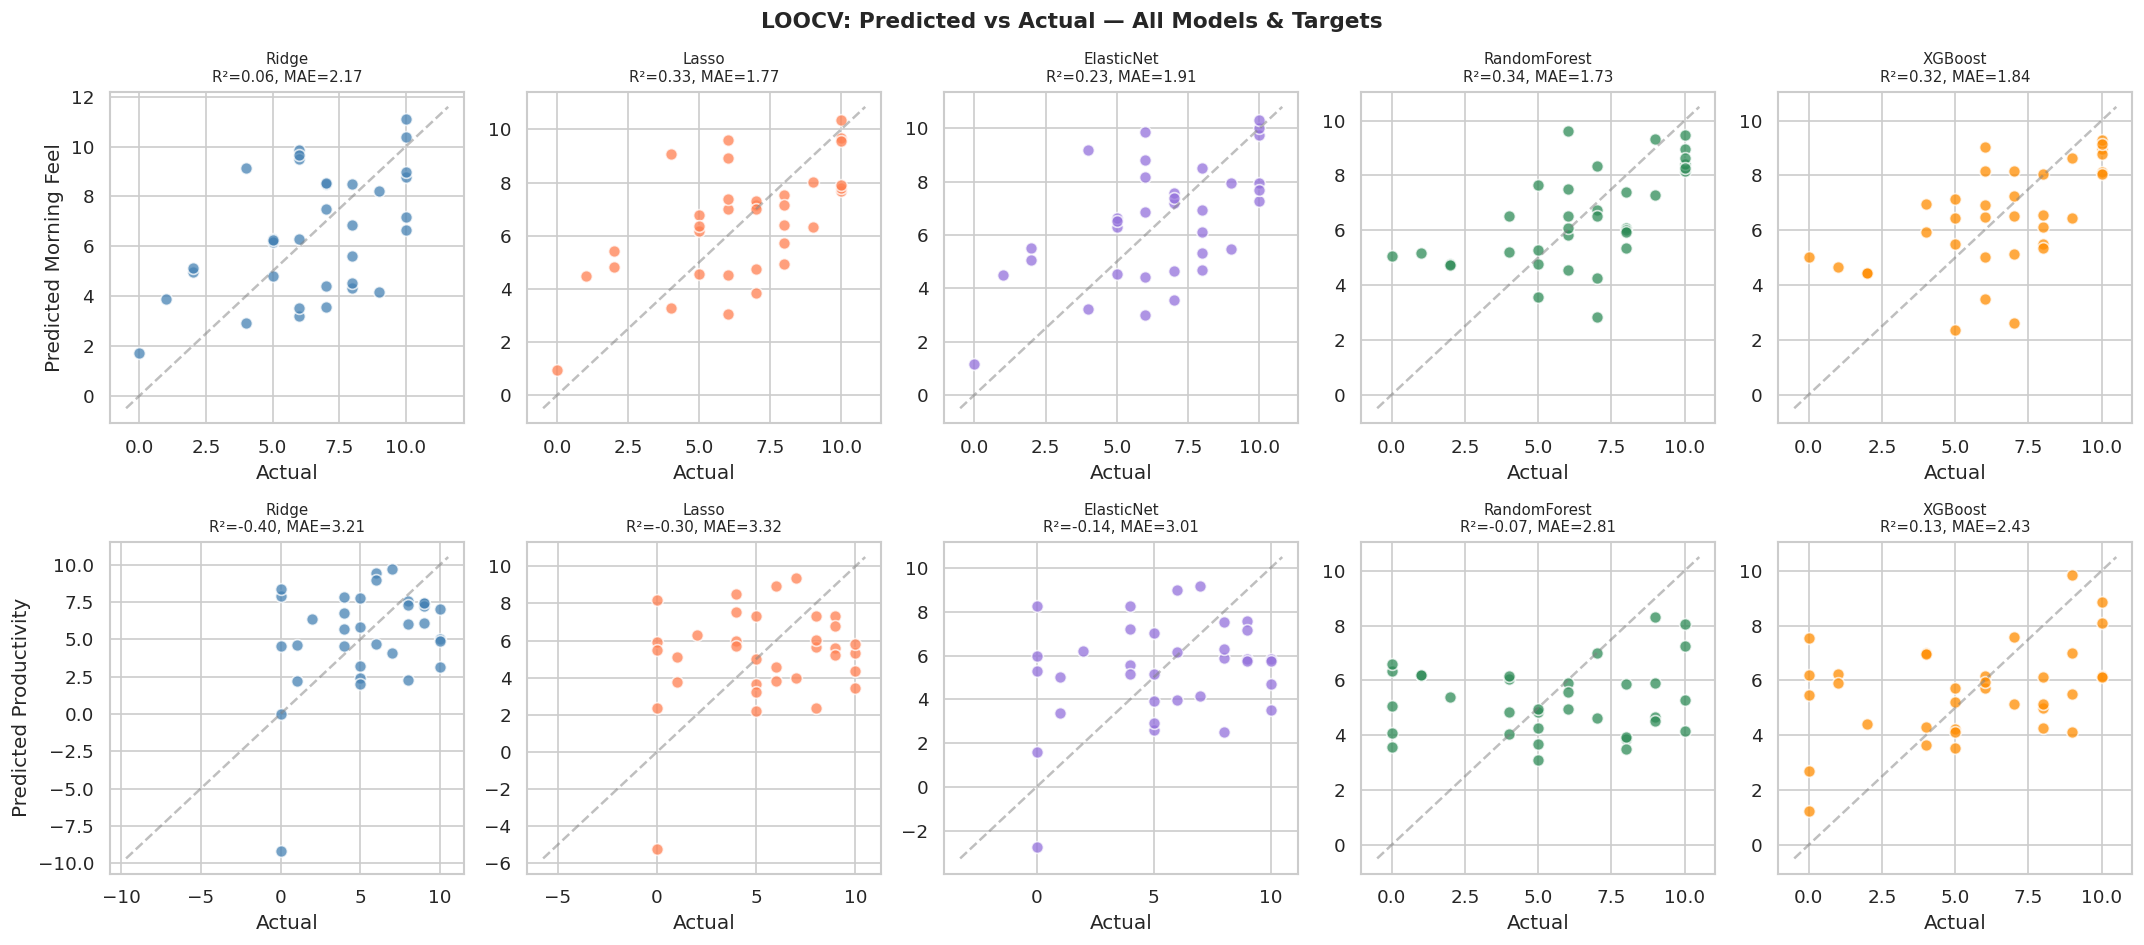

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.suptitle('LOOCV: Predicted vs Actual — All Models & Targets', fontsize=13, fontweight='bold')

model_names = list(models.keys())
colors = ['steelblue','coral','mediumpurple','seagreen','darkorange']

for row, (target_name, y) in enumerate([('morning_feel', y_feel), ('productivity', y_prod)]):
    for col, (name, color) in enumerate(zip(model_names, colors)):
        ax = axes[row][col]
        preds = predictions[target_name][name]
        r2 = results[target_name][name]['R2']
        mae = results[target_name][name]['MAE']
        ax.scatter(y, preds, color=color, alpha=0.75, s=50, edgecolors='white')
        lo, hi = min(y.min(), preds.min())-0.5, max(y.max(), preds.max())+0.5
        ax.plot([lo,hi],[lo,hi],'--',color='grey',alpha=0.5)
        ax.set_title(f'{name}\nR²={r2:.2f}, MAE={mae:.2f}', fontsize=9)
        if col == 0:
            label = 'Morning Feel' if target_name == 'morning_feel' else 'Productivity'
            ax.set_ylabel(f'Predicted {label}')
        ax.set_xlabel('Actual')

plt.tight_layout()
plt.savefig('predicted_vs_actual.png', bbox_inches='tight')
plt.show()

## 5. Model Comparison Summary

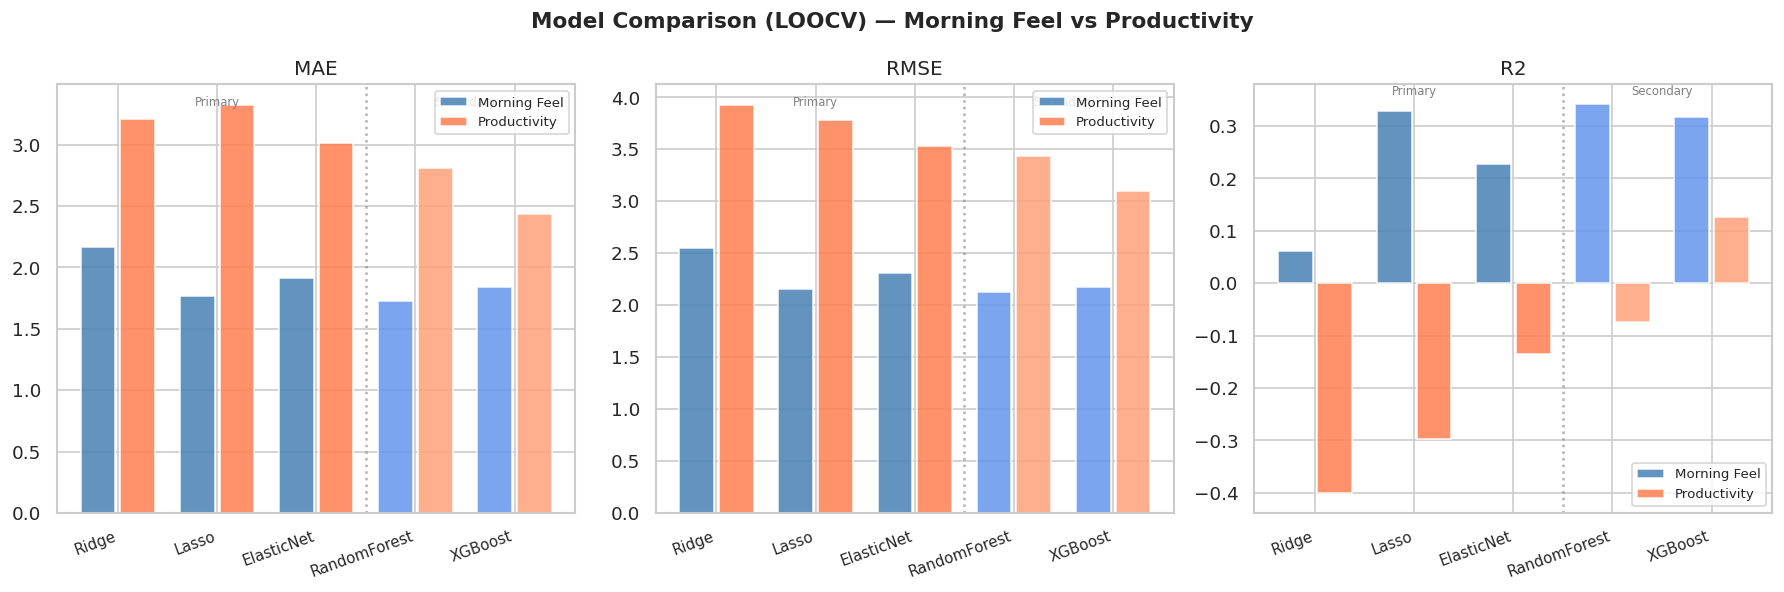

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Model Comparison (LOOCV) — Morning Feel vs Productivity', fontsize=13, fontweight='bold')

primary = ['Ridge','Lasso','ElasticNet']
secondary = ['RandomForest','XGBoost']

for i, metric in enumerate(['MAE','RMSE','R2']):
    ax = axes[i]
    feel_vals = [results['morning_feel'][m][metric] for m in model_names]
    prod_vals = [results['productivity'][m][metric] for m in model_names]
    x = np.arange(len(model_names))
    bars1 = ax.bar(x-0.2, feel_vals, 0.35, label='Morning Feel',
                   color=['steelblue' if m in primary else 'cornflowerblue' for m in model_names],
                   alpha=0.85)
    bars2 = ax.bar(x+0.2, prod_vals, 0.35, label='Productivity',
                   color=['coral' if m in primary else 'lightsalmon' for m in model_names],
                   alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=20, ha='right', fontsize=9)
    ax.set_title(metric)
    ax.legend(fontsize=8)
    ax.axvline(2.5, color='grey', linestyle=':', alpha=0.6, label='Primary | Secondary')
    ax.text(1.0, ax.get_ylim()[1]*0.95, 'Primary', ha='center', fontsize=7, color='grey')
    ax.text(3.5, ax.get_ylim()[1]*0.95, 'Secondary', ha='center', fontsize=7, color='grey')

plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()

## 6. SHAP Feature Importance — Best Primary Model

Best primary model — Morning Feel: Lasso
Best primary model — Productivity:  ElasticNet


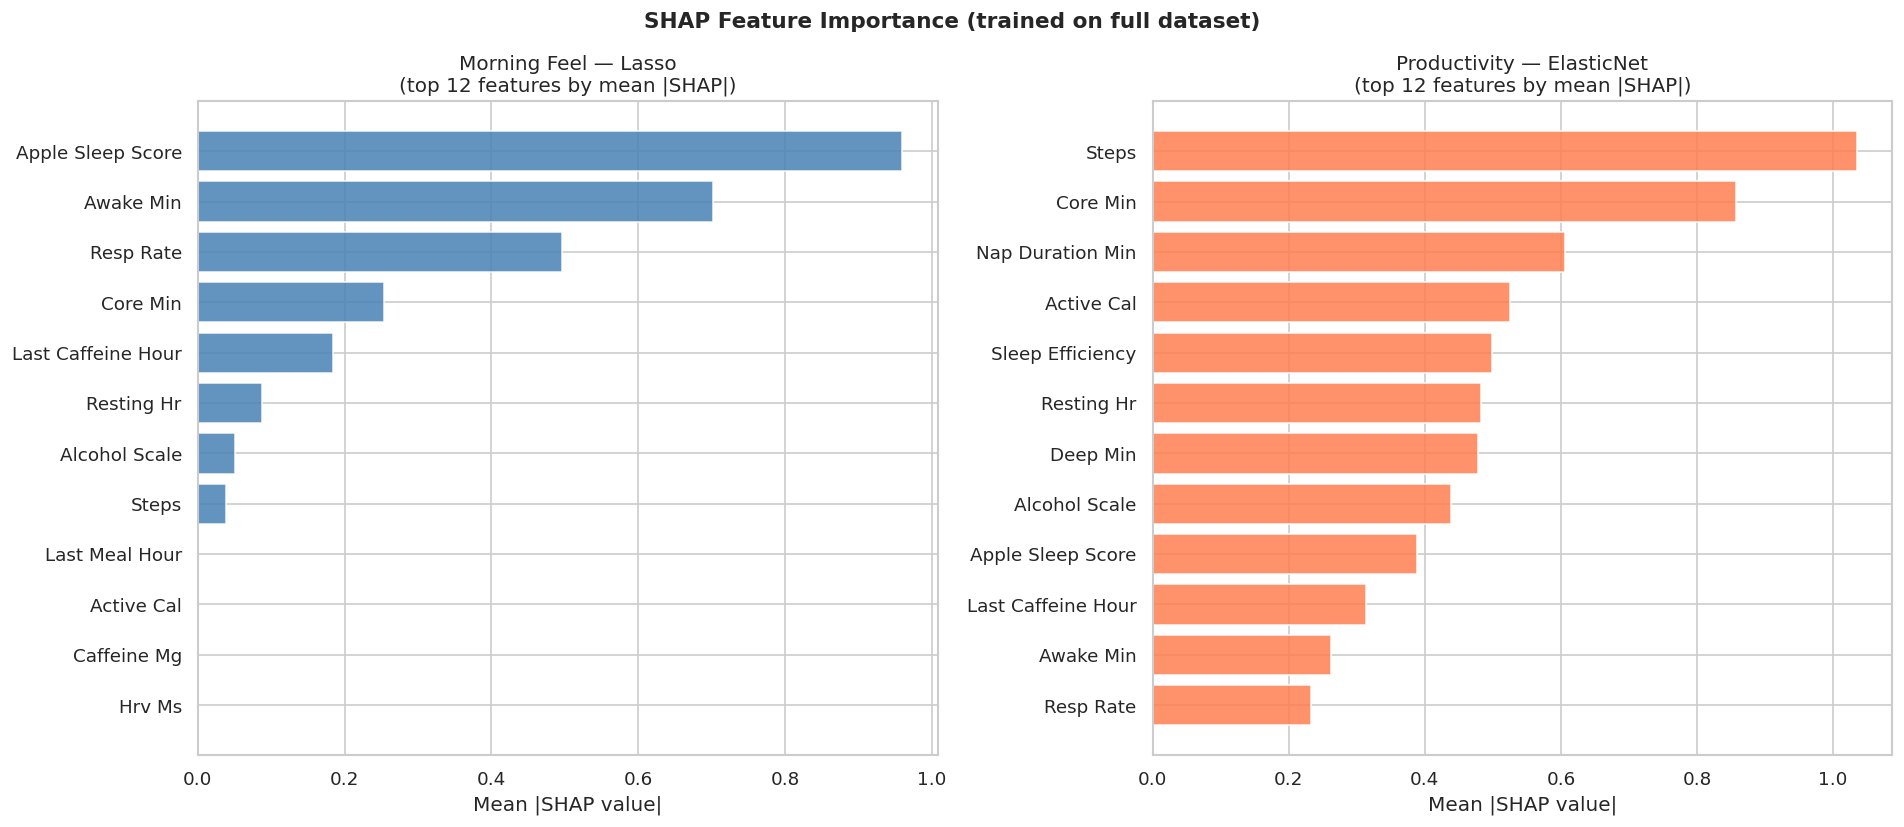

In [6]:
# Identify best primary model per target by lowest MAE
def best_primary(target):
    return min(primary, key=lambda m: results[target][m]['MAE'])

best_feel = best_primary('morning_feel')
best_prod  = best_primary('productivity')
print(f'Best primary model — Morning Feel: {best_feel}')
print(f'Best primary model — Productivity:  {best_prod}')

# Fit best models on full dataset for SHAP
feat_names = [f.replace('_',' ').title() for f in FEATURES]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('SHAP Feature Importance (trained on full dataset)', fontsize=13, fontweight='bold')

for ax, (target_name, y, best_name) in zip(axes, [
    ('morning_feel', y_feel, best_feel),
    ('productivity',  y_prod,  best_prod)
]):
    model = models[best_name]
    model.fit(X_scaled, y)
    explainer = shap.LinearExplainer(model, X_scaled, feature_perturbation='interventional')
    shap_vals = explainer.shap_values(X_scaled)
    mean_abs_shap = np.abs(shap_vals).mean(axis=0)
    order = np.argsort(mean_abs_shap)[::-1]
    top_n = 12
    ax.barh([feat_names[o] for o in order[:top_n]][::-1],
            mean_abs_shap[order[:top_n]][::-1],
            color='steelblue' if 'feel' in target_name else 'coral', alpha=0.85)
    label = 'Morning Feel' if 'feel' in target_name else 'Productivity'
    ax.set_title(f'{label} — {best_name}\n(top {top_n} features by mean |SHAP|)')
    ax.set_xlabel('Mean |SHAP value|')

plt.tight_layout()
plt.savefig('shap_importance.png', bbox_inches='tight')
plt.show()

## 7. SHAP Beeswarm — Direction of Feature Effects

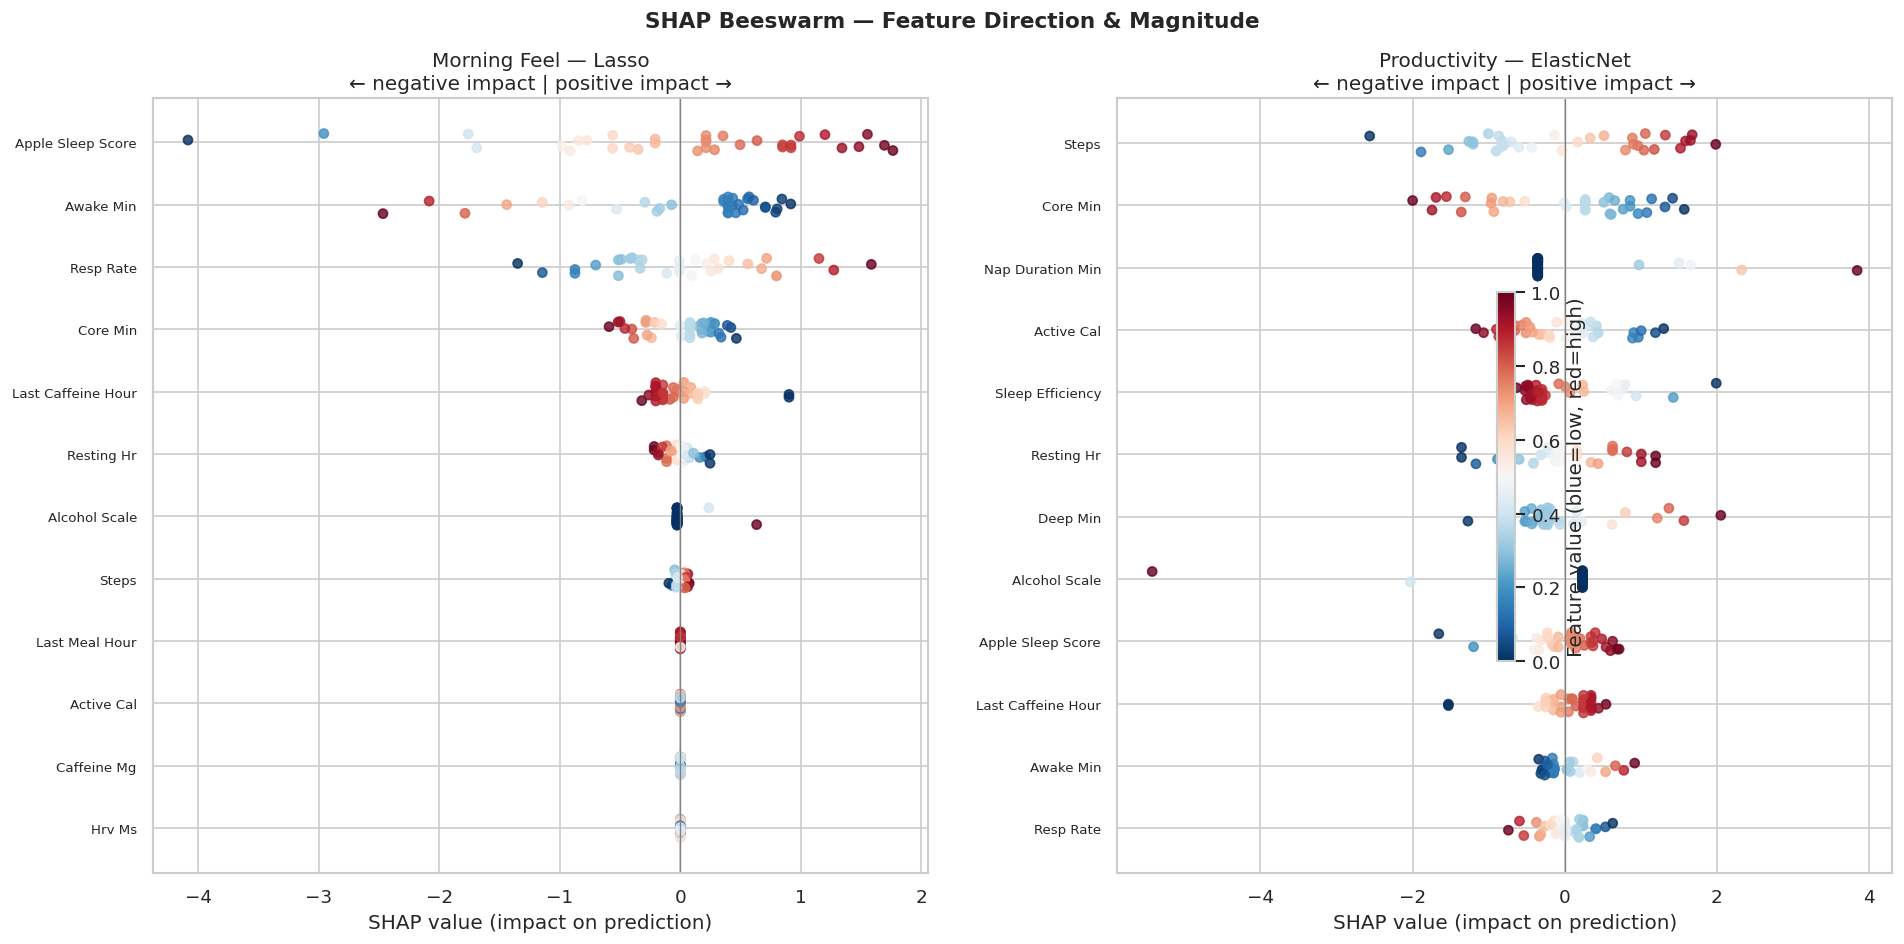

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('SHAP Beeswarm — Feature Direction & Magnitude', fontsize=13, fontweight='bold')

for ax, (target_name, y, best_name) in zip(axes, [
    ('morning_feel', y_feel, best_feel),
    ('productivity',  y_prod,  best_prod)
]):
    model = models[best_name]
    model.fit(X_scaled, y)
    explainer = shap.LinearExplainer(model, X_scaled, feature_perturbation='interventional')
    shap_vals = explainer.shap_values(X_scaled)
    mean_abs = np.abs(shap_vals).mean(axis=0)
    order = np.argsort(mean_abs)[::-1][:12]

    for j, fi in enumerate(order[::-1]):
        sv = shap_vals[:, fi]
        fv = X_scaled[:, fi]
        norm = plt.Normalize(fv.min(), fv.max())
        colors_pt = plt.cm.RdBu_r(norm(fv))
        jitter = np.random.uniform(-0.15, 0.15, len(sv))
        ax.scatter(sv, np.full(len(sv), j) + jitter,
                   c=colors_pt, s=30, alpha=0.8)

    ax.set_yticks(range(len(order)))
    ax.set_yticklabels([feat_names[i] for i in order[::-1]], fontsize=8)
    ax.axvline(0, color='grey', linewidth=0.8)
    ax.set_xlabel('SHAP value (impact on prediction)')
    label = 'Morning Feel' if 'feel' in target_name else 'Productivity'
    ax.set_title(f'{label} — {best_name}\n← negative impact | positive impact →')

sm = plt.cm.ScalarMappable(cmap='RdBu_r')
sm.set_array([])
fig.colorbar(sm, ax=axes, label='Feature value (blue=low, red=high)', shrink=0.5)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', bbox_inches='tight')
plt.show()

## 8. Dual-Target Joint Optimization

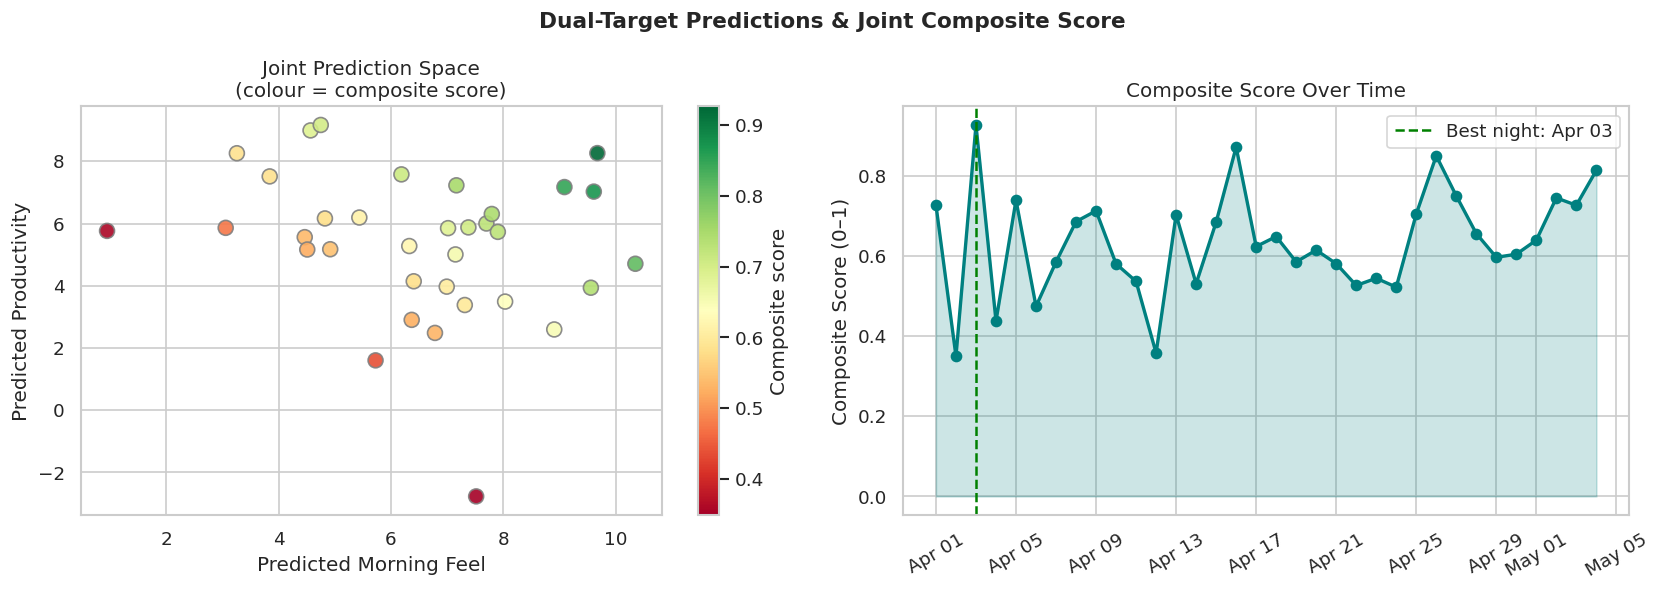

=== TOP 5 NIGHTS BY COMPOSITE SCORE ===
      date  duration_h  bedtime_hour  caffeine_mg  morning_feel  productivity  pred_feel  pred_prod  composite
2026-04-03        6.39          4.02          480            10           0.0       9.67       8.26       0.93
2026-04-16        6.88          2.60           40             6           5.0       9.61       7.03       0.87
2026-04-26         NaN           NaN          300             4           9.0       9.09       7.17       0.85
2026-05-04        5.09          4.12          340            10          10.0      10.35       4.71       0.81
2026-04-27        4.52          5.33          565             7           4.0       7.16       7.23       0.75


In [8]:
# Composite score = average of normalized predictions
feel_preds = predictions['morning_feel'][best_feel]
prod_preds  = predictions['productivity'][best_prod]

feel_norm = (feel_preds - feel_preds.min()) / (feel_preds.max() - feel_preds.min())
prod_norm  = (prod_preds  - prod_preds.min())  / (prod_preds.max()  - prod_preds.min())
composite  = (feel_norm + prod_norm) / 2

ml_df['pred_feel']  = feel_preds
ml_df['pred_prod']  = prod_preds
ml_df['composite']  = composite

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Dual-Target Predictions & Joint Composite Score', fontsize=13, fontweight='bold')

ax = axes[0]
ax.scatter(feel_preds, prod_preds, c=composite, cmap='RdYlGn', s=80, edgecolors='grey', alpha=0.9)
sm = plt.cm.ScalarMappable(cmap='RdYlGn',
     norm=plt.Normalize(composite.min(), composite.max()))
plt.colorbar(sm, ax=ax, label='Composite score')
ax.set_xlabel('Predicted Morning Feel')
ax.set_ylabel('Predicted Productivity')
ax.set_title('Joint Prediction Space\n(colour = composite score)')

ax = axes[1]
ax.plot(ml_df['date'], ml_df['composite'], 'o-', color='teal', linewidth=2)
ax.fill_between(ml_df['date'], ml_df['composite'], alpha=0.2, color='teal')
best_idx = composite.argmax()
ax.axvline(ml_df['date'].iloc[best_idx], color='green', linestyle='--',
           label=f'Best night: {ml_df["date"].iloc[best_idx].strftime("%b %d")}')
ax.set_ylabel('Composite Score (0–1)')
ax.set_title('Composite Score Over Time')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.savefig('joint_optimization.png', bbox_inches='tight')
plt.show()

print('=== TOP 5 NIGHTS BY COMPOSITE SCORE ===')
top5 = ml_df.nlargest(5, 'composite')[['date','duration_h','bedtime_hour',
    'caffeine_mg','morning_feel','productivity','pred_feel','pred_prod','composite']]
print(top5.round(2).to_string(index=False))

## 9. Personalized Optimal Sleep Routine

In [9]:
# Top-third nights by composite score — derive optimal conditions
top_threshold = np.percentile(composite, 67)
good_nights = ml_df[ml_df['composite'] >= top_threshold]
all_nights  = ml_df

print('=' * 62)
print('PERSONALIZED OPTIMAL SLEEP ROUTINE — Deniz Elbek')
print('Derived from top-third nights by joint composite score')
print('=' * 62)

def fmt_hour(h):
    if pd.isna(h): return 'N/A'
    return f"{int(h):02d}:{int((h%1)*60):02d}"

metrics_to_report = [
    ('duration_h',         'Sleep Duration',        '{:.1f}h'),
    ('bedtime_hour',       'Bedtime',                None),
    ('wake_hour',          'Wake Time',              None),
    ('caffeine_mg',        'Daily Caffeine',         '{:.0f}mg'),
    ('last_caffeine_hour', 'Last Caffeine',          None),
    ('last_meal_hour',     'Last Meal',              None),
    ('alcohol_scale',      'Alcohol (0–5 scale)',    '{:.1f}'),
    ('steps',              'Daily Steps',            '{:,.0f}'),
    ('exercise_min',       'Exercise',               '{:.0f} min'),
    ('nap_duration_min',   'Nap Duration',           '{:.0f} min'),
]

for col, label, fmt in metrics_to_report:
    good_val = good_nights[col].median()
    all_val  = all_nights[col].median()
    if fmt is None:
        good_str = fmt_hour(good_val)
        all_str  = fmt_hour(all_val)
    else:
        good_str = fmt.format(good_val)
        all_str  = fmt.format(all_val)
    print(f'{label:<25} Optimal: {good_str:<12} Overall median: {all_str}')

print('\n' + '=' * 62)
print('SUMMARY RECOMMENDATION')
print('=' * 62)
bed = fmt_hour(good_nights['bedtime_hour'].median())
wake = fmt_hour(good_nights['wake_hour'].median())
caf  = good_nights['caffeine_mg'].median()
lcaf = fmt_hour(good_nights['last_caffeine_hour'].median())
meal = fmt_hour(good_nights['last_meal_hour'].median())
dur  = good_nights['duration_h'].median()
print(f'Sleep window  : {bed} → {wake} (~{dur:.1f}h)')
print(f'Caffeine      : ≤{caf:.0f}mg/day, last intake by {lcaf}')
print(f'Last meal     : by {meal}')
print(f'Alcohol       : {good_nights["alcohol_scale"].median():.0f}/5 (minimise)')
print(f'Daily steps   : ≥{good_nights["steps"].median():,.0f}')

PERSONALIZED OPTIMAL SLEEP ROUTINE — Deniz Elbek
Derived from top-third nights by joint composite score
Sleep Duration            Optimal: 7.3h         Overall median: 8.1h
Bedtime                   Optimal: 04:01        Overall median: 04:00
Wake Time                 Optimal: 10:25        Overall median: 11:56
Daily Caffeine            Optimal: 300mg        Overall median: 300mg
Last Caffeine             Optimal: 15:00        Overall median: 18:30
Last Meal                 Optimal: 19:00        Overall median: 20:00
Alcohol (0–5 scale)       Optimal: 0.0          Overall median: 0.0
Daily Steps               Optimal: 20,974       Overall median: 15,266
Exercise                  Optimal: 47 min       Overall median: 30 min
Nap Duration              Optimal: 0 min        Overall median: 0 min

SUMMARY RECOMMENDATION
Sleep window  : 04:01 → 10:25 (~7.3h)
Caffeine      : ≤300mg/day, last intake by 15:00
Last meal     : by 19:00
Alcohol       : 0/5 (minimise)
Daily steps   : ≥20,974


## 10. Summary & Limitations

### Key Findings
- Dual-target LOOCV models successfully predict both morning feel rating and daily productivity from sleep and lifestyle features.
- Regularized linear models (Ridge/Lasso/ElasticNet) serve as the primary approach, appropriate for n=28.
- SHAP values reveal the features with greatest personal impact on each outcome.
- The joint composite score identifies specific nights and conditions that simultaneously maximize both targets, forming the basis of a personalized routine recommendation.

### Limitations
- **Sample size (n=28 complete nights):** Small dataset limits generalizability and statistical power. 6 nights were excluded due to Apple Watch not being worn.
- **Self-reporting bias:** Morning feel and productivity ratings are subjective and may be inconsistently calibrated across the 34-day period.
- **Environmental confound:** Elevated awake_min on several nights is attributable to external noise (roommate snoring) rather than controllable lifestyle factors.
- **Missing HRV/SpO₂ for early nights:** Apple Watch requires a calibration period; first 5 nights lack these physiological metrics, handled via median imputation.
- **No screen time data:** Apple Screen Time export was not integrated in this milestone due to extraction complexity; planned for final report.
- **Causality:** All findings are correlational. The model identifies associations, not causal relationships.